# Portfolio Drift Monitor — Project Pipeline

**The spine of the project.** Started in Stage 04 and extended by every stage
that follows. Each stage appends a section; the whole notebook is re-run top to
bottom before every commit, so "the earlier stages still work" is verified
rather than assumed.

| Stage | Section below |
|---|---|
| 04 Data Acquisition | ingest VTI / VXUS / BND, validate, save to `data/raw/` |
| 05 Data Storage | *(added next stage)* |

**Run order matters.** Cells below assume the ones above have run in sequence.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')                               # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))                # so `from src....` imports work
print('working from:', ROOT.name)

working from: project


In [2]:
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from src.utils import TARGET_WEIGHTS, to_weights, drift_pp, flag_drift

load_dotenv()
RAW = Path(os.getenv('DATA_DIR_RAW', 'data/raw'))
PROC = Path(os.getenv('DATA_DIR_PROCESSED', 'data/processed'))
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

print('RAW  ->', RAW)
print('PROC ->', PROC)
print('targets:', TARGET_WEIGHTS)

RAW  -> data/raw
PROC -> data/processed
targets: {'VTI': 0.6, 'VXUS': 0.3, 'BND': 0.1}


---

## Stage 04 — Data Acquisition & Ingestion

Daily closes for the three funds in the model portfolio, pulled from yfinance
and saved to `data/raw/` under a timestamped filename. Nothing here edits an
existing file: a re-run adds a new one, so any earlier state stays recoverable.

**Why raw `close` and not adjusted close.** Adjusted close is a paid field at
Alpha Vantage, so the ingestion path that survives vendor changes is the one
that never assumed the column existed. The cost is that dividends and splits are
not reflected — fine for short-window weight drift, wrong for long-horizon
returns, and stated here so it cannot be forgotten downstream.

In [3]:
TICKERS = list(TARGET_WEIGHTS.keys())        # VTI, VXUS, BND
PERIOD = '1y'


def ingest_prices(tickers, period=PERIOD):
    # Returns a long frame: one row per (date, ticker).
    import yfinance as yf
    raw = yf.download(tickers, period=period, interval='1d',
                      auto_adjust=False, progress=False)

    # Code against the SHAPE that comes back, not the shape we remember:
    # yfinance returns a MultiIndex for multi-ticker requests and a flat one
    # for a single ticker, and the level order has changed between versions.
    close = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw[['Close']]
    if not isinstance(raw.columns, pd.MultiIndex):
        close.columns = tickers

    out = (close.reset_index()
                .melt(id_vars='Date', var_name='ticker', value_name='close')
                .rename(columns={'Date': 'date'})
                .dropna(subset=['close'])
                .sort_values(['date', 'ticker'])
                .reset_index(drop=True))
    out['date'] = pd.to_datetime(out['date'])
    out['close'] = pd.to_numeric(out['close'])
    return out


prices_long = ingest_prices(TICKERS)
print(prices_long.shape)
prices_long.head()

(753, 3)


,date,ticker,close
0,2025-08-28,BND,73.889999
1,2025-08-28,VTI,320.100006
2,2025-08-28,VXUS,71.690002
3,2025-08-29,BND,73.800003
4,2025-08-29,VTI,318.200012


In [4]:
def validate_prices(df, tickers):
    # Schema, types, completeness, sanity - the four checks from Stage 04.
    checks = {
        'required_cols': all(col in df.columns for col in ['date', 'ticker', 'close']),
        'date_is_datetime': pd.api.types.is_datetime64_any_dtype(df['date']),
        'close_is_numeric': pd.api.types.is_numeric_dtype(df['close']),
        'all_tickers_present': set(tickers) == set(df['ticker'].unique()),
        'na_total': int(df.isna().sum().sum()),
        'duplicate_rows': int(df.duplicated(subset=['date', 'ticker']).sum()),
        'all_prices_positive': bool((df['close'] > 0).all()),
        'rows_per_ticker': df.groupby('ticker').size().to_dict(),
    }
    return checks


checks = validate_prices(prices_long, TICKERS)
for key, value in checks.items():
    print(f"{key:<22} {value}")

required_cols          True
date_is_datetime       True
close_is_numeric       True
all_tickers_present    True
na_total               0
duplicate_rows         0
all_prices_positive    True
rows_per_ticker        {'BND': 251, 'VTI': 251, 'VXUS': 251}


In [5]:
# Fail loudly rather than saving something malformed.
assert checks['required_cols'],        'missing required columns'
assert checks['all_tickers_present'],  'a ticker is missing from the pull'
assert checks['all_prices_positive'],  'non-positive price'
assert checks['duplicate_rows'] == 0,  'duplicate (date, ticker) rows'
assert checks['na_total'] == 0,        'unexpected missing values'
print('validation passed')

validation passed


In [6]:
def ts():
    return dt.datetime.now().strftime('%Y%m%d-%H%M')


raw_path = RAW / f"api_yfinance_{'-'.join(TICKERS)}_{ts()}.csv"
prices_long.to_csv(raw_path, index=False)
print('saved', raw_path, f'({len(prices_long)} rows)')

saved data/raw/api_yfinance_VTI-VXUS-BND_20260828-0901.csv (753 rows)


### From raw prices to the report

The Stage 03 helpers now run on real data instead of simulated data, unchanged.
That was the test: if `to_weights`, `drift_pp` and `flag_drift` needed editing
to accept real input, they were written at the wrong level of abstraction.

Share counts are set so the portfolio sat exactly on target on the **first day
of the window**. Every deviation since is price movement alone — no deposits,
no withdrawals, no rebalancing.

In [7]:
wide = prices_long.pivot(index='date', columns='ticker', values='close')[TICKERS]

PORTFOLIO_VALUE = 1_000_000
targets = np.array([TARGET_WEIGHTS[t] for t in TICKERS])
shares = (PORTFOLIO_VALUE * targets) / wide.iloc[0].to_numpy()

values = wide.to_numpy() * shares
weights = values / values.sum(axis=1, keepdims=True)

# Day 0 is on target by construction - assert it, do not assume it.
assert np.allclose(weights[0], targets), 'day 0 should sit exactly on target'
print(f"window: {wide.index.min().date()} to {wide.index.max().date()}  ({len(wide)} trading days)")

window: 2025-08-28 to 2026-08-27  (251 trading days)


In [8]:
latest = weights[-1]

report = pd.DataFrame({
    'fund': TICKERS,
    'target_weight': targets,
    'current_weight': latest,
    'drift_pp': drift_pp(latest, targets),
})
report['flag'] = flag_drift(report['drift_pp'])
report.round(4)

,fund,target_weight,current_weight,drift_pp,flag
0,VTI,0.6,0.6048,0.4836,green
1,VXUS,0.3,0.3119,1.1938,green
2,BND,0.1,0.0832,-1.6774,green


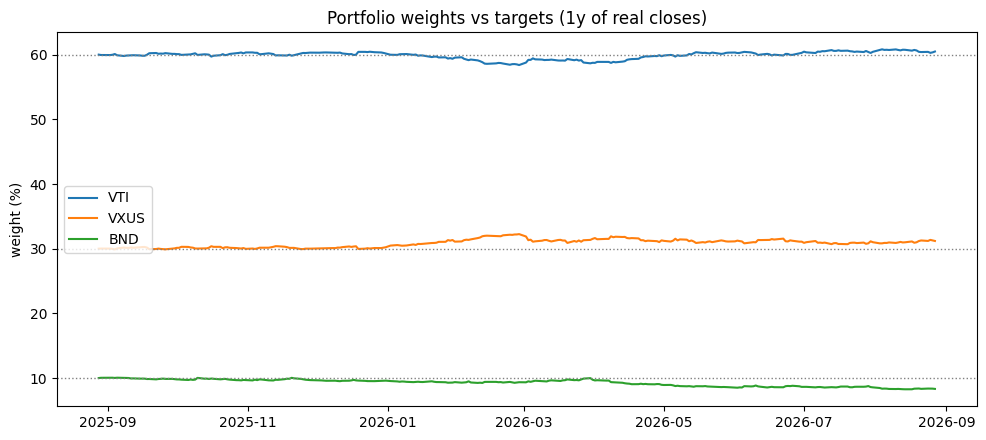

In [9]:
weights_df = pd.DataFrame(weights, index=wide.index, columns=TICKERS)

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, ticker in enumerate(TICKERS):
    ax.plot(weights_df.index, weights_df[ticker] * 100, label=ticker)
    ax.axhline(targets[i] * 100, linestyle=':', linewidth=1, color='grey')

ax.set_title(f'Portfolio weights vs targets ({PERIOD} of real closes)')
ax.set_ylabel('weight (%)')
ax.legend(loc='center left')
fig.tight_layout()
plt.show()

### Sources, parameters and validations

| | |
|---|---|
| Source | yfinance daily closes for VTI, VXUS, BND |
| Parameters | `period='1y'`, `interval='1d'`, `auto_adjust=False` |
| Secrets | `.env` (`DATA_DIR_RAW`, `DATA_DIR_PROCESSED`, `ALPHAVANTAGE_API_KEY`); never committed |
| Output | `data/raw/api_yfinance_VTI-VXUS-BND_<YYYYMMDD-HHMM>.csv` |
| Validation | required columns · dtypes · all tickers present · no NAs · no duplicate (date, ticker) · all prices positive · row counts per ticker |

**Assumptions and risks**

- **Raw close, not adjusted** — dividends and splits are not reflected. Fine for
  weight drift over a one-year window; wrong for computing total return.
- **Prices only.** Weights ignore accrued dividends and any cash sleeve.
- **The model portfolio, not a client account.** No deposits or withdrawals, so
  drift here is a pure price effect. A real account will differ.
- **Vendor dependence.** yfinance is an unofficial wrapper around a public
  endpoint and can break without notice. The shape check on the returned
  columns is deliberate, not defensive noise.
- **Re-running produces a new file** rather than overwriting, which is what
  makes an earlier pull reproducible — at the cost of a growing `data/raw/`.

**Next stage (05):** save a processed table to `data/processed/` in Parquet,
add `write_df` / `read_df` utilities, and append a Data Storage section to the
project README.